In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import os
import cv2
import re

In [77]:
path = os.listdir('/kaggle/input/datasets/dasmehdixtr/drone-dataset-uav/dataset_xml_format/dataset_xml_format')

In [78]:
base_path = '/kaggle/input/datasets/dasmehdixtr/drone-dataset-uav/dataset_xml_format/dataset_xml_format'
images = [i for i in os.listdir(base_path) if i.endswith('.png')]

In [79]:
X = []
y = []
for i in images:
    try:
        image_path = os.path.join(base_path, i)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        shape_x = image.shape[1]
        shape_y = image.shape[0]
        image = cv2.resize(image, (224,224))
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        X.append(image)
        xml_path = image_path.replace('.png', '.xml')
        with open(xml_path, 'r', encoding='utf-8') as file:
            text = file.read()
        xmin,ymin,xmax,ymax = map(int, re.findall(r'(?:<xmin>|<ymin>|<xmax>|<ymax>)(\d*)(?:</xmin>|</ymin>|</xmax>|</ymax>)', text)[:4])
        xmin = xmin * 224 / shape_x
        ymin = ymin * 224 / shape_y
        xmax = xmax * 224 / shape_x
        ymax = ymax * 224 / shape_y
        y.append([xmin,ymin,xmax,ymax])
        flipped_image = cv2.flip(image, 1)
        f_xmin = 224 - xmax
        f_xmax = 224 - xmin
        X.append(flipped_image)
        y.append([f_xmin,ymin,f_xmax,ymax])
    except:
        print('no')
X = np.array(X)
y = np.array(y)

In [80]:
X.shape, y.shape

((600, 224, 224, 3), (600, 4))

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
y_train = y_train / 224.0
y_test = y_test / 224.0

In [84]:
y_train[0]

array([0.38046875, 0.46944444, 0.46953125, 0.55555556])

In [85]:
from keras import Sequential, layers
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.applications import EfficientNetB0
from keras.optimizers import Adam

In [86]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

In [101]:
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [102]:
model = Sequential([

base_model,
GlobalAveragePooling2D(),

Dense(512, activation='relu'),
Dropout(0.4),
Dense(256, activation='relu'),
Dropout(0.2),
Dense(4, activation='sigmoid')
])

In [103]:
model.compile(optimizer=Adam(learning_rate=0.00002), loss='mae')

In [104]:
model.fit(X_train,y_train, validation_split=0.15, epochs=50, batch_size=32)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - loss: 0.1649 - val_loss: 0.1310
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - loss: 0.1398 - val_loss: 0.1140
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 0.1281 - val_loss: 0.1047
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - loss: 0.1248 - val_loss: 0.0991
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 0.1159 - val_loss: 0.0941
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 0.1129 - val_loss: 0.0893
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - loss: 0.1057 - val_loss: 0.0861
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 0.1004 - val_loss: 0.0831
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.0982 - val_loss: 0.0811
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.1005 - val_loss: 0.0797
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - loss: 0.0972 - val_loss: 0.0792
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - loss: 0.0949 - val_lo

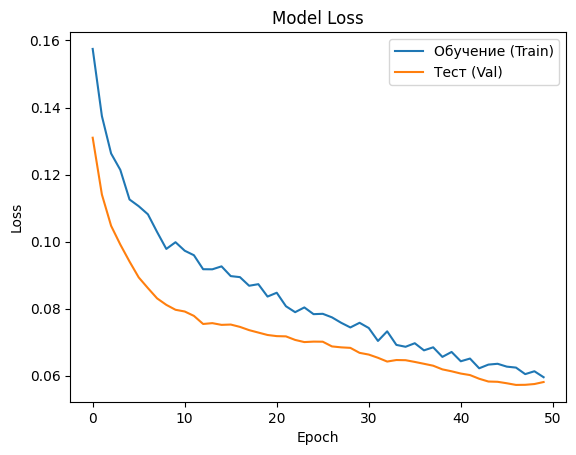

In [117]:
plt.plot(model.history.history['loss'], label='Обучение (Train)')
plt.plot(model.history.history['val_loss'], label='Тест (Val)')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [108]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 765ms/step - loss: 0.0727


0.06888333708047867

In [ ]:
model.save('drone_detection_model.h5')

#### TEST

In [109]:
new_ = img.imread('/kaggle/input/datasets/samvelgalstyan/ggggggggg/drone3.jfif')

In [110]:
new_image = new_.copy()

In [111]:
new_.shape, new_image.shape

((168, 300, 3), (168, 300, 3))

In [112]:
new_image = cv2.resize(new_image, (224,224))
new_image = new_image.reshape(1,224,224,3)

In [113]:
xmin,ymin,xmax,ymax = map(int, model.predict(new_image)[0] * 224)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [114]:
xmin,ymin,xmax,ymax

(55, 34, 167, 170)

In [115]:
new_image = new_image.reshape(224,224,3).astype('uint8')

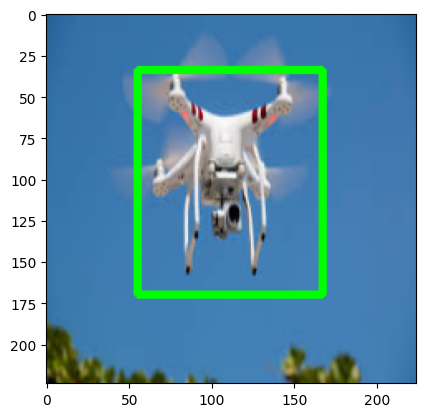

In [116]:
plt.imshow(cv2.rectangle(new_image, (xmin,ymin),(xmax,ymax), (0,255,0), 3))